In [15]:
# 设置显示中文字体，
import matplotlib.pyplot as plt
from pylab import mpl
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"] ## mac
plt.rcParams['font.family']=['Arial Unicode MS'] ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
# -*- coding: gbk -*-
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import copy
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警
plt.rcParams['font.sans-serif']=['SimSun']
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1,scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc,scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean
def CARS_Cloud(X, y, N=50, f=20, cv=10):
    p = 0.99
    m, n = X.shape
    u = np.power((n/2), (1/(N-1)))
    k = (1/(N-1)) * np.log(n/2)
    cal_num = np.round(m * p)
    val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    WaveData = []
    Coeff = []
    WaveNum =[]
    RMSECV = []
    r = []
    for i in range(1, N+1):
        r.append(u*np.exp(-1*k*i))
        # current_r = u * np.sqrt(np.exp(-1 * k * i))
        # r.append(current_r)  # 将当前 r 值添加到 r 数组中 
        wave_num = int(np.round(r[i-1]*n))
        WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice    \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        # xcal = xcal[:,wave_index].reshape(-1,wave_num)
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1,-1)
        wnum = n - wave_num
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -1)))
        if len(WaveData) == 0:
            WaveData = d
        else:
            WaveData  = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f,scale=False)
        pls.fit(xcal, ycal)
        beta = pls.coef_
        b = np.abs(beta)
        b2 = np.argsort(-b, axis=0)
        coef = copy.deepcopy(beta)
        coeff = coef[b2, :].reshape(len(b2), -1)
        cb = coeff[:wave_num]

        if wnum > 0:
            cb = np.vstack((cb, np.full((wnum, 1), -1)))
        if len(Coeff) == 0:
            Coeff = copy.deepcopy(cb)
        else:
            Coeff = np.hstack((Coeff, cb))
        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        RMSECV.append(Cross_Validation(xcal, ycal, rindex+1, cv))
    CoeffData = Coeff.T

    WAVE = []
    COEFF = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        cd = CoeffData[i, :]
        WD = np.ones((len(wd)))
        CO = np.ones((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
                CO[j] = 0
            else:
                WD[j] = wd[ind[0]]
                CO[j] = cd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))
        if len(COEFF) == 0:
            COEFF = copy.deepcopy(CO)
        else:
            COEFF = np.vstack((WAVE, CO.reshape(1, -1)))
    print(WaveData)
    print(WAVE)
    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave=np.array(OptWave)
    OptWave=list(OptWave)
    # fig = plt.figure(figsize = (8,7))
    # # plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    # plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    # fonts = 16
    # # plt.subplot(311)
    # plt.xlabel('Monte Carlo iterations\n(a)', fontsize=fonts)
    # plt.ylabel('Number of selected variables', fontsize=fonts)
    # plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    # plt.plot(np.arange(N), WaveNum)
    # 
    # fig2 = plt.figure(figsize = (8,7))
    # # plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    # plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    # fonts = 16
    # # plt.subplot(312)
    # plt.xlabel('Monte Carlo iterations\n(b)', fontsize=fonts)
    # plt.ylabel('RMSECV', fontsize=fonts)
    # plt.plot(np.arange(N), RMSECV)
    # 
    # # fig3 = plt.figure(figsize = (8,7))
    # # # plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    # # plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    # # fonts = 16
    # # # plt.subplot(313)
    # # plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    # # plt.ylabel('各变量系数值', fontsize=fonts)
    # # plt.plot(COEFF)
    # # plt.vlines(MinIndex, -1e3, 1e3, colors='r')
    # plt.show()
    return (OptWave)

import pandas as pd
# data=pd.read_excel(r"/Users/mac/data/FL199.xlsx").values

if __name__ == "__main__":
    import scipy.io as scio
    # import pandas as pd
    # 导入数据
    # Absorbance data, collected in the matrix X
    data=pd.read_excel(r"/Users/macbook/folder/data/pre/mscFLMA_N.xlsx").values
    X = data[:,1:]
    y = data[:,0]
    cars_index=CARS_Cloud(X, y)


[[  0.   1.   2. ... 221. 222. 223.]
 [ 23.  75.   4. ...  -1.  -1.  -1.]
 [ 23.  75. 172. ...  -1.  -1.  -1.]
 ...
 [ 18.  23.  -1. ...  -1.  -1.  -1.]
 [ 18.  23.  -1. ...  -1.  -1.  -1.]
 [ 18.  23.  -1. ...  -1.  -1.  -1.]]
[[  0.   1.   2. ... 221. 222. 223.]
 [  0.   1.   2. ... 221. 222. 223.]
 [  0.   1.   2. ... 221. 222.   0.]
 ...
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]]


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
import random
from sklearn.ensemble import RandomForestRegressor
# data=pd.read_excel(r"/Users/mac/Downloads/FL199.xlsx").values
data_y=data[:,0]
data_x=data[:,1:]
best_features=cars_index
print(len(best_features))
print(best_features)

33
[10, 13, 18, 21, 23, 24, 33, 36, 37, 54, 66, 70, 88, 90, 94, 116, 122, 132, 136, 147, 150, 152, 158, 159, 162, 163, 171, 183, 186, 193, 199, 207, 212]


In [17]:
features_select=[]
for i in best_features:
    features_select.append(data_x[:,i])
features_select=np.array(features_select)
features_select=features_select.transpose()
x_train,x_test,y_train,y_test = train_test_split(features_select,data_y,test_size=0.25,random_state=30)



In [18]:
pls_model_setup = PLSRegression(scale=False)
param_grid = {'n_components': range(1, x_train.shape[1])}
gsearch = GridSearchCV(pls_model_setup, param_grid,cv=5)
pls_model = gsearch.fit(x_train, y_train)
# pls_model.fit(x_train, y_train)

In [19]:
pls_y_train = pls_model.predict(x_train)
pls_y_test = pls_model.predict(x_test)
pls_r2_train = r2_score(y_train,pls_y_train)
pls_r2_test = r2_score(y_test,pls_y_test)
pls_rmse_train = np.sqrt(mean_squared_error(y_train,pls_y_train))
pls_rmse_test = np.sqrt(mean_squared_error(y_test,pls_y_test))
print("PLS-CARS_train",pls_r2_train,pls_rmse_train)
print("PLS-CARS_test",pls_r2_test,pls_rmse_test)

PLS-CARS_train 0.9050221055528893 0.12812384816814548
PLS-CARS_test 0.9371528401632487 0.12111204001138529


In [20]:
boduan=np.linspace(942, 1701, X.shape[1])
newbd = boduan[best_features[:]]
# newbd

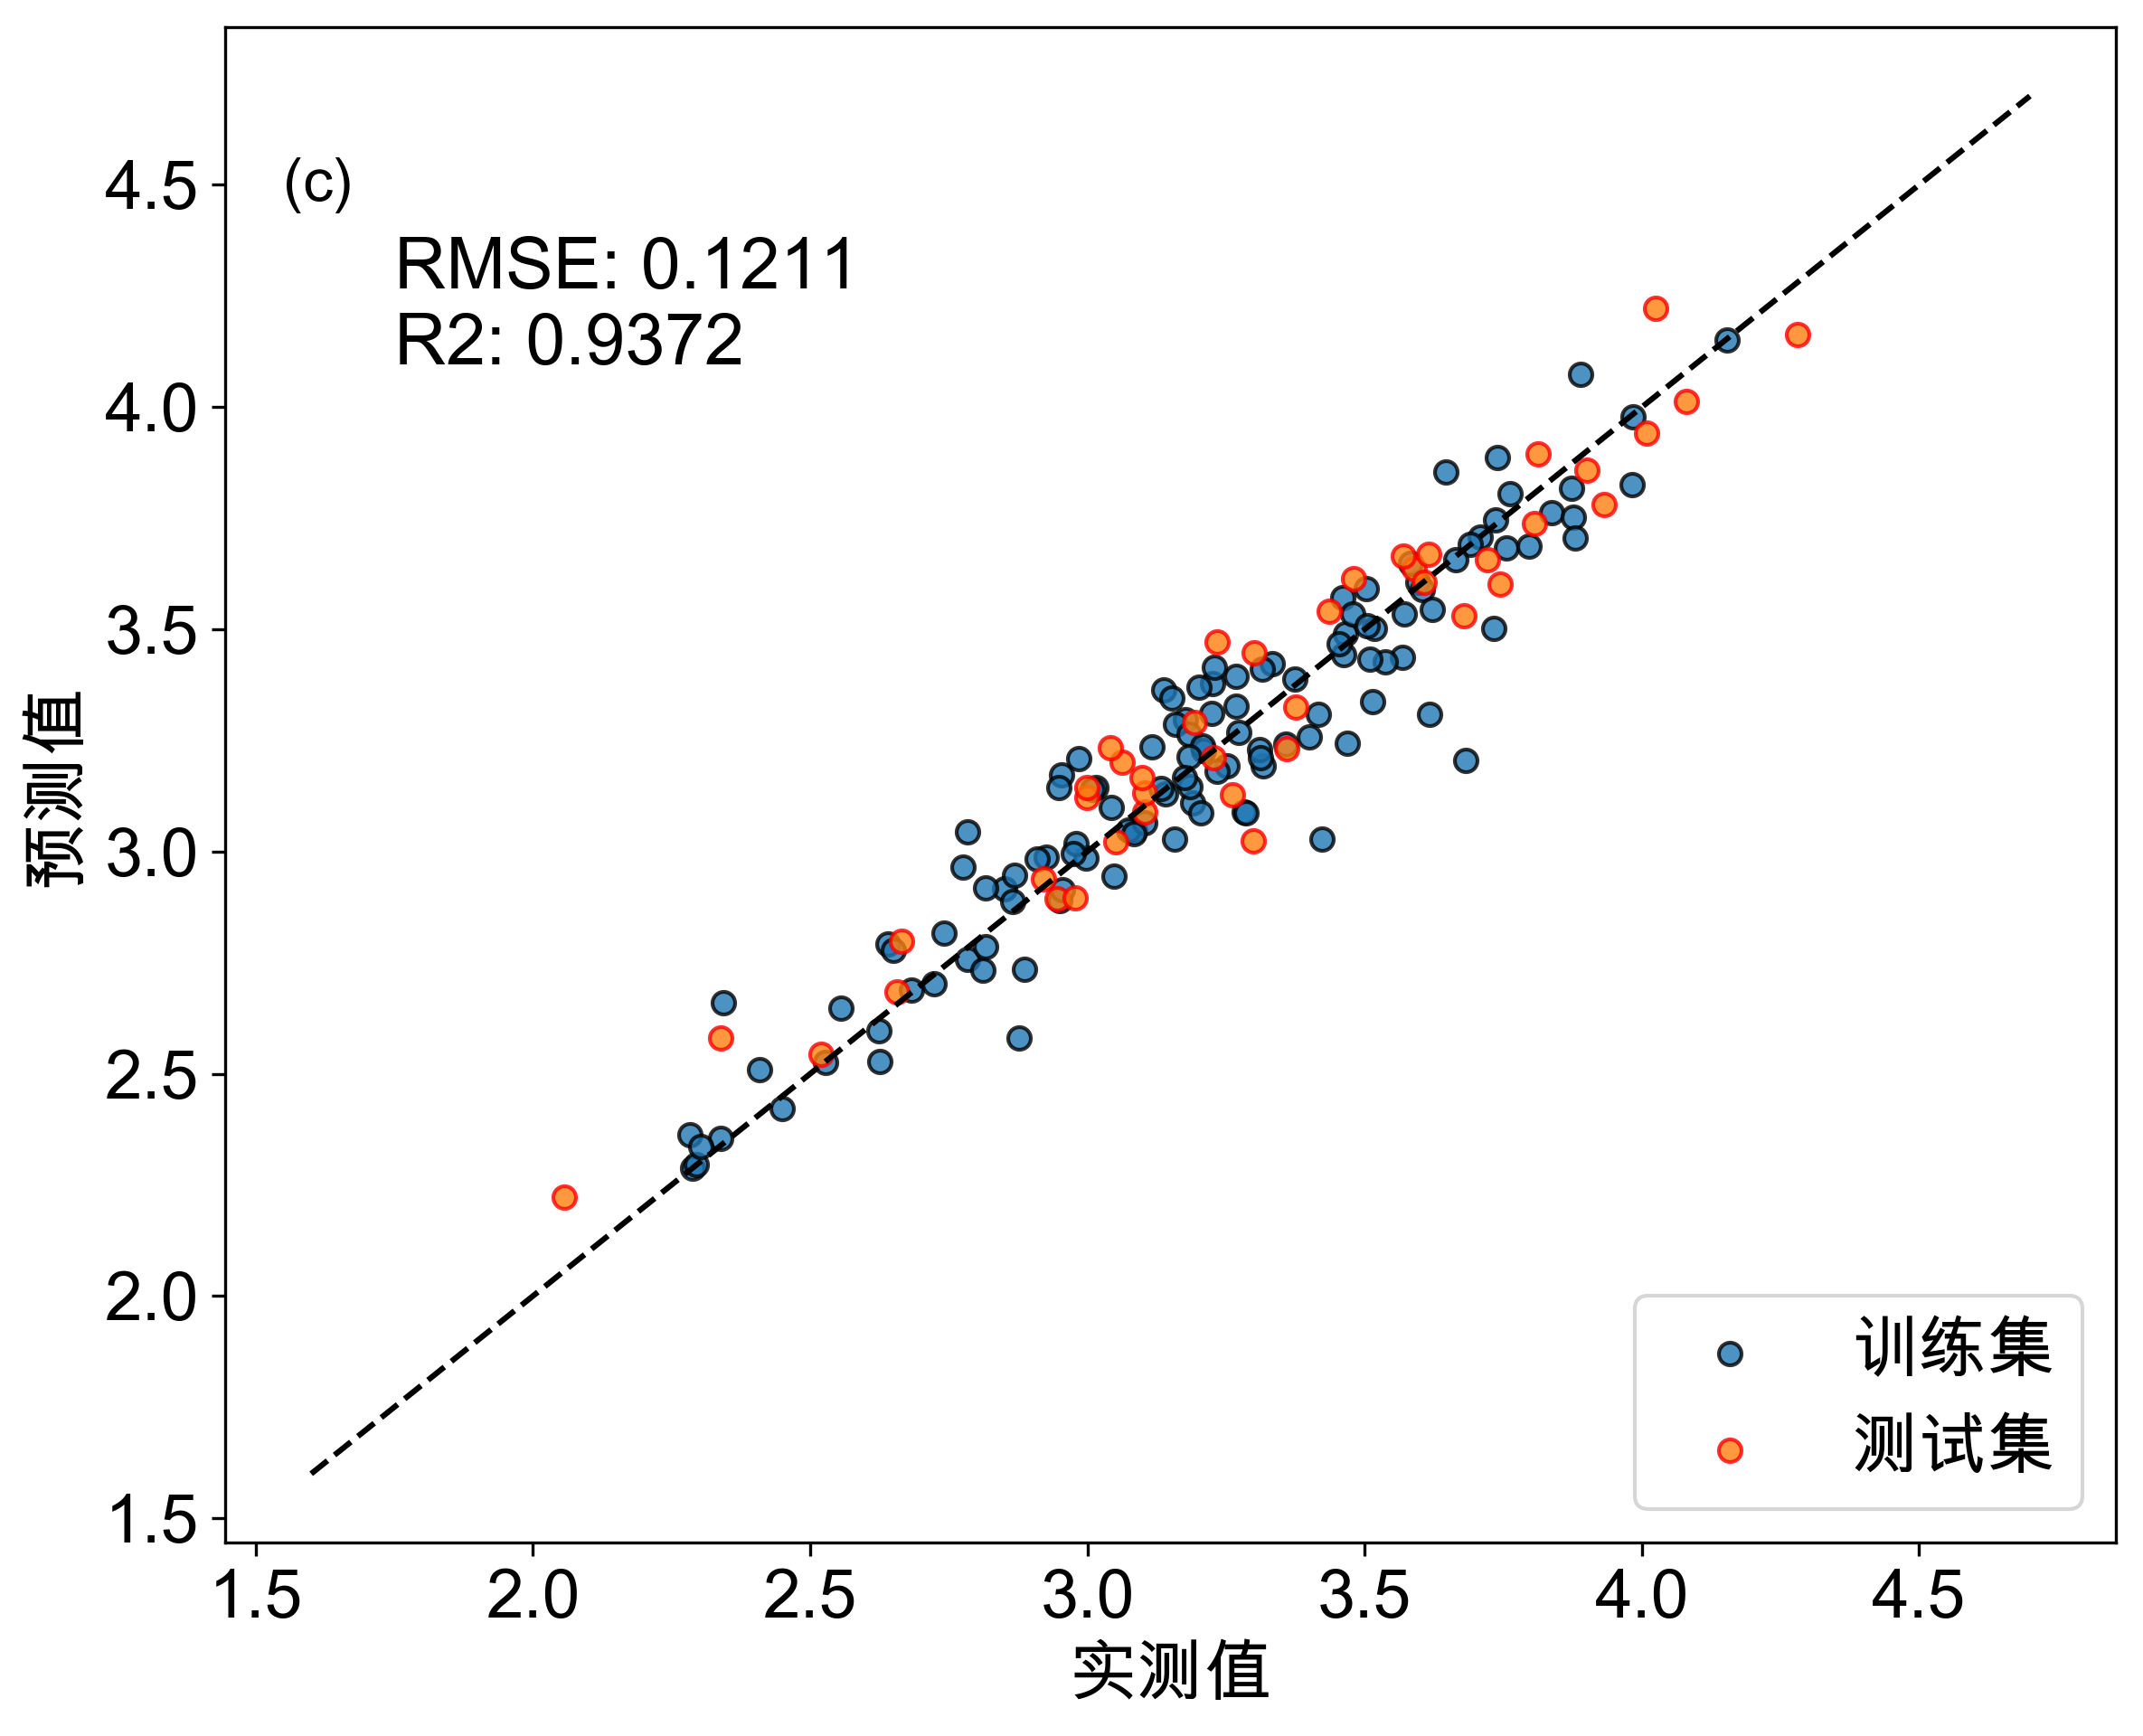

In [ ]:
import matplotlib

# with plt.style.context(('seaborn-whitegrid')):  
plt.figure(figsize=(8, 6.5))  

# x = np.linspace(1.5, 4.5, 7)
# y = np.linspace(1.5, 4.5, 7)

# Scatter plot of X vs Y  
plt.scatter(y_train, pls_y_train, label='训练集', edgecolors='k', alpha=0.8)  
plt.scatter(y_test, pls_y_test, label='测试集', edgecolors='r', alpha=0.8)  

# Plot of the 45 degree line  
plt.plot([1.6, 4.7], [1.6, 4.7], color='black', linestyle='--')  
# Create a FontProperties object for the text  
fontprops = matplotlib.font_manager.FontProperties(style='italic')  
plt.text(1.55, 0.99 * pls_y_test.max(), "(c)\n\n", fontsize=16, color='black')  
title=plt.text(1.75, 0.97 * pls_y_test.max(), "  \nRMSE: {:.4f}\nR2: {:.4f}".format(pls_rmse_test, pls_r2_test), fontsize=19, color='black')  
title.set_fontstyle('italic')
plt.grid(False)  
plt.xticks(fontsize=18)  
plt.yticks(fontsize=18)  
# plt.title('PC selection by CARS', fontsize=18)  
plt.xlabel('实测值', fontsize=18)  
plt.ylabel('预测值', fontsize=18)  

plt.legend(loc='lower right', prop={'size': 18})  # 添加图例并放在右下角，并且设置图例字体大小为16，样式为斜体   

# # 保存为TIFF格式
# plt.savefig('/Users/macbook/Desktop/论文原图/拟合图a.tif', format='tiff', dpi=300, bbox_inches='tight')
# # 保存为JPG格式
# plt.savefig('/Users/macbook/Desktop/论文原图/拟合图a.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.tight_layout()
# plt.savefig('/Users/macbook/Desktop/论文11_24/图11c.svg')
# plt.savefig('/Users/macbook/Desktop/论文11_24/图11c.eps',format='eps')
# plt.savefig('/Users/macbook/Desktop/论文11_24/图11c.pdf',format='pdf')
plt.show() 
